In [1]:
import os 
os.chdir('../../')
os.environ["DPM_TQDM"] = "False"
os.environ["CUDA_VISIBLE_DEVICES"]="1"

!nvidia-smi

Sun Aug 31 04:58:44 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.76.05              Driver Version: 580.76.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        Off |   00000000:19:00.0 Off |                  N/A |
| 30%   47C    P8             12W /  575W |    7923MiB /  32607MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
from backbones.dit import DiT

# 사용 예
model = DiT(dtype=torch.bfloat16)
print(model)

/home/scpark/miniconda3/envs/dual/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]An error occurred while trying to fetch /home/scpark/.cache/huggingface/hub/models--facebook--DiT-XL-2-256/snapshots/eab87f77abd5aef071a632f08807fbaab0b704d0/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/scpark/.cache/huggingface/hub/models--facebook--DiT-XL-2-256/snapshots/eab87f77abd5aef071a632f08807fbaab0b704d0/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...:  67%|██████▋   | 2/3 [00:00<00:00, 18.31it/s]An error occurred while trying to fetch /home/scpark/.cache/huggingface/hub/models--facebook--DiT-XL-2-256/snapshots/eab87f77abd5aef071a

In [3]:
import torch
from PIL import Image

# ==================== helpers (PIL display) ====================
@torch.no_grad()
def latents_to_pils(pipe, latents):
    imgs = pipe.vae.decode(latents / pipe.vae.config.scaling_factor).sample  # [-1,1], [B,3,H,W]
    imgs = ((imgs.clamp(-1, 1) + 1) * 127.5).to(torch.uint8).permute(0,2,3,1).cpu().numpy()
    return [Image.fromarray(a, mode="RGB") for a in imgs]

def pil_grid(pils, ncols=5, pad=4, bg=(240,240,240)):
    w, h = pils[0].size
    nrows = (len(pils) + ncols - 1) // ncols
    grid = Image.new("RGB", (ncols*w + (ncols+1)*pad, nrows*h + (nrows+1)*pad), bg)
    k = 0
    for r in range(nrows):
        for c in range(ncols):
            if k >= len(pils): break
            grid.paste(pils[k], (pad + c*(w+pad), pad + r*(h+pad)))
            k += 1
    return grid




tensor([0.0063, 0.0167, 0.0395, 0.0830, 0.1611, 0.2796, 0.4401, 0.6296, 0.8107,
        0.9463, 0.9999], device='cuda:0')
tensor([1.0000, 0.9999, 0.9992, 0.9965, 0.9869, 0.9601, 0.8979, 0.7769, 0.5854,
        0.3234, 0.0100], device='cuda:0')


/tmp/ipykernel_16780/453331793.py:9: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return [Image.fromarray(a, mode="RGB") for a in imgs]


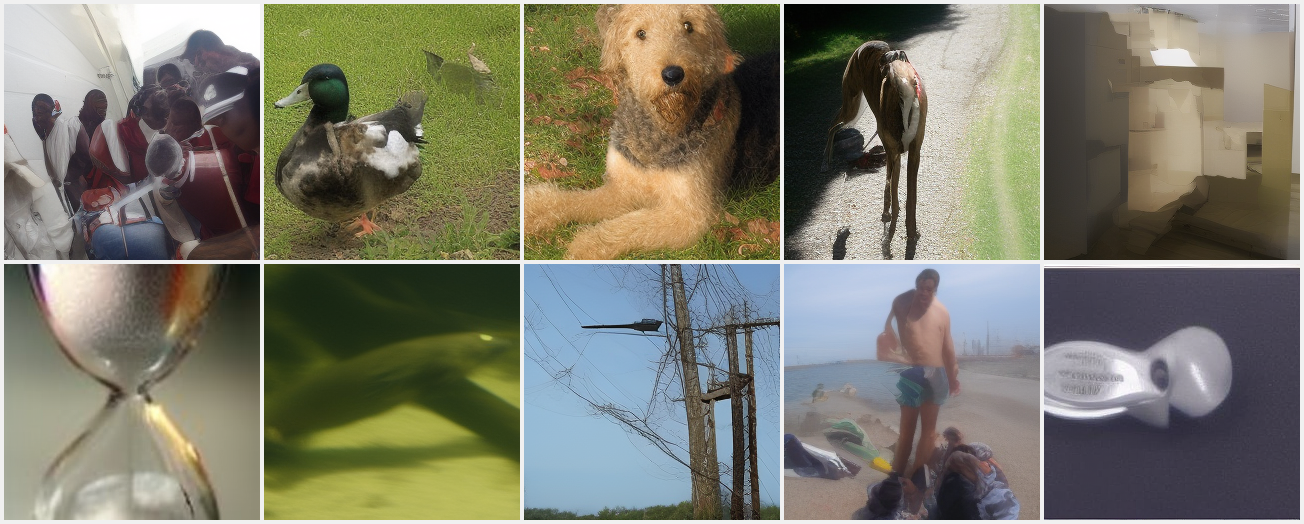

In [4]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.bfloat16

# Config
B, steps, cfg_scale = 10, 10, 1.5

# Euler (noise-pred mode)
# Seed 고정 (CPU, CUDA, 연산결정성)
seed = 0
torch.manual_seed(seed)

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

labels = torch.randint(0, 1000, (B,), device=device)
noises = torch.randn(B, 4, 32, 32, device=device, dtype=dtype)

from solvers.others.dpm_solver import DPM_Solver
from solvers.others.euler_solver import Euler_Solver

noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule=noise_schedule, pos_conds=labels, guidance_scale=cfg_scale)

solver = Euler_Solver(noise_schedule, steps=steps, skip_type='time_uniform', algorithm_type="noise_prediction")
latents = solver.sample(noises, model_fn)['samples']
grid_e = pil_grid(latents_to_pils(model.pipe, latents.to(dtype)), ncols=5)
display(grid_e)

# solver = DPM_Solver(noise_schedule, steps=steps, skip_type='time_uniform', algorithm_type="data_prediction")
# latents = solver.sample(noises, model_fn)['samples']
# grid_e = pil_grid(latents_to_pils(model.pipe, latents.to(dtype)), ncols=5)
# display(grid_e)

In [5]:
torch.save({'dpm' : latents.float().detach().cpu()}, f='dpm2.pt')

In [6]:
image1 = torch.load('dpm1.pt')['dpm']
image2 = torch.load('dpm2.pt')['dpm']
torch.allclose(image1, image2)

False

In [9]:
torch.mean(torch.abs(image1 - image2))

tensor(0.0557)

In [ ]:
tensor([0.0063, 0.0167, 0.0395, 0.0830, 0.1611, 0.2796, 0.4401, 0.6296, 0.8107,
        0.9463, 0.9999], device='cuda:0')
tensor([1.0000, 0.9999, 0.9992, 0.9965, 0.9869, 0.9601, 0.8979, 0.7769, 0.5854,
        0.3234, 0.0100], device='cuda:0')
        
tensor([0.0064, 0.0166, 0.0391, 0.0835, 0.1609, 0.2803, 0.4418, 0.6296, 0.8118,
        0.9471, 1.0000], device='cuda:0')
tensor([1.0000, 0.9999, 0.9992, 0.9965, 0.9870, 0.9599, 0.8971, 0.7769, 0.5839,
        0.3209, 0.0000], device='cuda:0')

In [ ]:
sigma가 0이 안되는탓일까?